In [3]:
import pandas as pd

df = pd.read_csv('/Users/nitinramesh/Downloads/cleaned_data.csv').drop_duplicates()
df = df[~df['reference'].str.contains('the most informative paragraph:', na=False)]
df = df.dropna(subset=['reference', 'output'])
df = df.reset_index(drop=True)

print(f"Total pairs to evaluate: {len(df)}")
print(f"\nGround-truth label distribution:")
print(df['label'].value_counts())
print(f"\nHallucination types:")
print(df['hallucination_type_realized'].value_counts())
df.head(3)

Total pairs to evaluate: 7819

Ground-truth label distribution:
label
factual         5161
hallucinated    2658
Name: count, dtype: int64

Hallucination types:
hallucination_type_realized
Relation-error hallucination              689
Incompleteness hallucination              638
Overclaim hallucination                   448
Entity-error hallucination                410
Unverifiable information hallucination    240
Outdated information hallucination        233
Name: count, dtype: int64


,reference,input,output,label,hallucination_type_realized,question_type,hallucination_type_encouraged
0,"A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...","What organization has accredited A.D.A.M., Inc...","A.D.A.M., Inc. is accredited by the Atlantis H...",hallucinated,Entity-error hallucination,Default question type,Entity-error hallucination
1,"""This dataset for NOAA's Science On a Sphere d...",What type of educational activity is encourage...,The dataset encourages learners to complete a ...,hallucinated,Relation-error hallucination,Default question type,Relation-error hallucination
2,"Dimension items include ""Foreground"" and ""Back...",What is the primary reason for a hit to be cla...,The primary reason for a hit to be classified ...,hallucinated,Relation-error hallucination,Other common hallucinated questions,Other hallucination


In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "cross-encoder/nli-deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Confirm label order — important, varies by model
id2label = model.config.id2label
print("Label mapping:", id2label)
print(f"Running on: {device}")

config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Label mapping: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}
Running on: cpu


In [7]:
import torch.nn.functional as F

def score_pair(reference: str, claim: str, max_length: int = 512) -> dict:
    """
    Score a (reference, claim) pair using NLI.
    
    Args:
        reference: Ground-truth reference text (premise)
        claim: LLM response to verify (hypothesis)
        max_length: Token limit — long texts will be truncated
    
    Returns:
        Dict with scores for each NLI label, top verdict, and confidence
    """
    inputs = tokenizer(
        reference,
        claim,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
        padding=True
    ).to(device)
    
    with torch.no_grad():
        logits = model(**inputs).logits
    
    probs = F.softmax(logits, dim=-1).squeeze().cpu().tolist()
    scores = {id2label[i]: round(p, 4) for i, p in enumerate(probs)}
    verdict = max(scores, key=scores.get)
    
    return {**scores, 'verdict': verdict, 'confidence': scores[verdict]}


# Sanity check — expect CONTRADICTION
test = score_pair(
    reference="The study found no significant link between coffee and heart disease.",
    claim="Coffee increases the risk of heart disease according to the study."
)
print(test)

{'contradiction': 0.9998, 'entailment': 0.0, 'neutral': 0.0001, 'verdict': 'contradiction', 'confidence': 0.9998}


In [9]:
from tqdm import tqdm

results = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Fact-checking"):
    scores = score_pair(row['reference'], row['output'])
    results.append(scores)

results_df = pd.DataFrame(results)
output_df = pd.concat([df.reset_index(drop=True), results_df], axis=1)

print(output_df['verdict'].value_counts())
output_df.head(3)

Fact-checking: 100%|████████████████████████| 7819/7819 [12:50<00:00, 10.15it/s]

verdict
neutral          4008
entailment       3279
contradiction     532
Name: count, dtype: int64


,reference,input,output,label,hallucination_type_realized,question_type,hallucination_type_encouraged,contradiction,entailment,neutral,verdict,confidence
0,"A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...","What organization has accredited A.D.A.M., Inc...","A.D.A.M., Inc. is accredited by the Atlantis H...",hallucinated,Entity-error hallucination,Default question type,Entity-error hallucination,0.0001,0.0092,0.9907,neutral,0.9907
1,"""This dataset for NOAA's Science On a Sphere d...",What type of educational activity is encourage...,The dataset encourages learners to complete a ...,hallucinated,Relation-error hallucination,Default question type,Relation-error hallucination,0.9992,0.0000,0.0007,contradiction,0.9992
2,"Dimension items include ""Foreground"" and ""Back...",What is the primary reason for a hit to be cla...,The primary reason for a hit to be classified ...,hallucinated,Relation-error hallucination,Other common hallucinated questions,Other hallucination,0.0011,0.0000,0.9988,neutral,0.9988


In [11]:
ENTAILMENT_THRESHOLD = 0.6  # minimum confidence to accept an entailment as PASS

def moderation_flag(row):
    if row['verdict'] == 'contradiction':
        return 'FAIL'
    elif row['verdict'] == 'neutral':
        return 'UNVERIFIABLE'
    elif row['verdict'] == 'entailment' and row['confidence'] < ENTAILMENT_THRESHOLD:
        return 'REVIEW'
    else:
        return 'PASS'

output_df['moderation'] = output_df.apply(moderation_flag, axis=1)
print(output_df['moderation'].value_counts())

moderation
UNVERIFIABLE    4008
PASS            3232
FAIL             532
REVIEW            47
Name: count, dtype: int64


In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Map NLI verdict to binary prediction
# neutral is treated as 'factual' here since it means no contradiction was found
# adjust if you want neutral treated as hallucinated (stricter)
def nli_to_binary(verdict):
    if verdict == 'contradiction':
        return 'hallucinated'
    else:  # entailment or neutral
        return 'factual'

output_df['nli_prediction'] = output_df['verdict'].apply(nli_to_binary)

y_true = output_df['label']
y_pred = output_df['nli_prediction']

print(classification_report(y_true, y_pred, target_names=['factual', 'hallucinated']))

              precision    recall  f1-score   support

     factual       0.68      0.97      0.80      5161
hallucinated       0.67      0.13      0.22      2658

    accuracy                           0.68      7819
   macro avg       0.68      0.55      0.51      7819
weighted avg       0.68      0.68      0.60      7819



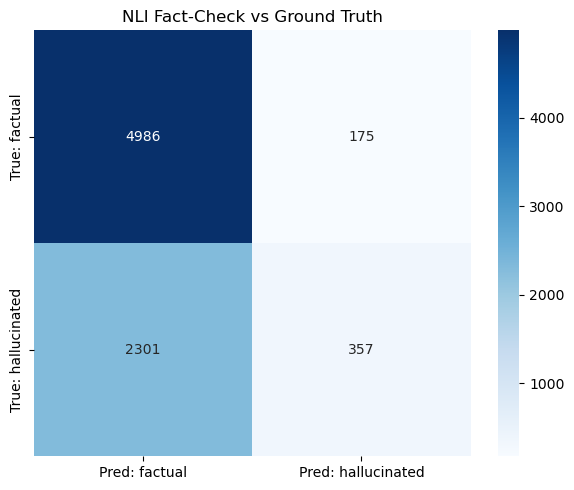

In [15]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=['factual', 'hallucinated'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: factual', 'Pred: hallucinated'],
            yticklabels=['True: factual', 'True: hallucinated'], ax=ax)
ax.set_title('NLI Fact-Check vs Ground Truth')
plt.tight_layout()
plt.show()

In [17]:
# Break down NLI performance by hallucination type
hallucinated_rows = output_df[output_df['label'] == 'hallucinated'].copy()
hallucinated_rows['correctly_flagged'] = hallucinated_rows['nli_prediction'] == 'hallucinated'

by_type = hallucinated_rows.groupby('hallucination_type_realized')['correctly_flagged'].agg(['sum', 'count'])
by_type['detection_rate'] = (by_type['sum'] / by_type['count']).round(3)
by_type.columns = ['detected', 'total', 'detection_rate']
print(by_type.sort_values('detection_rate', ascending=False))

                                        detected  total  detection_rate
hallucination_type_realized                                            
Entity-error hallucination                   123    410           0.300
Relation-error hallucination                 160    689           0.232
Incompleteness hallucination                  38    638           0.060
Outdated information hallucination            13    233           0.056
Overclaim hallucination                       20    448           0.045
Unverifiable information hallucination         3    240           0.012


In [19]:
false_negatives = output_df[
    (output_df['label'] == 'hallucinated') &
    (output_df['nli_prediction'] == 'factual')
][['reference', 'output', 'verdict', 'confidence', 'hallucination_type_realized']]

print(f"False negatives (missed hallucinations): {len(false_negatives)}")
false_negatives.head(5)

False negatives (missed hallucinations): 2301


,reference,output,verdict,confidence,hallucination_type_realized
0,"A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...","A.D.A.M., Inc. is accredited by the Atlantis H...",neutral,0.9907,Entity-error hallucination
2,"Dimension items include ""Foreground"" and ""Back...",The primary reason for a hit to be classified ...,neutral,0.9988,Relation-error hallucination
3,"Atlas Search runs a new process, called mongot...","Based on our production monitoring data, mongo...",neutral,0.9998,Unverifiable information hallucination
4,The business implications are stark. In a surv...,34% of banking executives in the loan originat...,neutral,0.9991,Relation-error hallucination
5,"Since 2003, Mount Aso’s Naka-dake crater has p...",The exact time when the volcano was producing ...,neutral,0.9992,Relation-error hallucination


In [21]:
output_df.to_csv('fact_check_results.csv', index=False)
print("Saved to fact_check_results.csv")
output_df.head()

Saved to fact_check_results.csv


,reference,input,output,label,hallucination_type_realized,question_type,hallucination_type_encouraged,contradiction,entailment,neutral,verdict,confidence,moderation,nli_prediction
0,"A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...","What organization has accredited A.D.A.M., Inc...","A.D.A.M., Inc. is accredited by the Atlantis H...",hallucinated,Entity-error hallucination,Default question type,Entity-error hallucination,0.0001,0.0092,0.9907,neutral,0.9907,UNVERIFIABLE,factual
1,"""This dataset for NOAA's Science On a Sphere d...",What type of educational activity is encourage...,The dataset encourages learners to complete a ...,hallucinated,Relation-error hallucination,Default question type,Relation-error hallucination,0.9992,0.0000,0.0007,contradiction,0.9992,FAIL,hallucinated
2,"Dimension items include ""Foreground"" and ""Back...",What is the primary reason for a hit to be cla...,The primary reason for a hit to be classified ...,hallucinated,Relation-error hallucination,Other common hallucinated questions,Other hallucination,0.0011,0.0000,0.9988,neutral,0.9988,UNVERIFIABLE,factual
3,"Atlas Search runs a new process, called mongot...",What are the specific hardware requirements fo...,"Based on our production monitoring data, mongo...",hallucinated,Unverifiable information hallucination,Other common hallucinated questions,Other hallucination,0.0001,0.0001,0.9998,neutral,0.9998,UNVERIFIABLE,factual
4,The business implications are stark. In a surv...,What percentage of banking executives in the l...,34% of banking executives in the loan originat...,hallucinated,Relation-error hallucination,Other common hallucinated questions,Other hallucination,0.0008,0.0002,0.9991,neutral,0.9991,UNVERIFIABLE,factual
